# Thực hành về mạng GAN

In [ ]:
# !nvidia-smi
# from google.colab import drive
# drive.mount('/content/drive')
# !pip3 install torchsummary
# !pip3 install torchvision

### Chuẩn bị các thư viện cần thiết

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import glob
import cv2
import torch.nn.functional as F
from tensorflow.python.keras.saving.saved_model_experimental import sequential
from torch.autograd import Variable

import torchvision
import torchvision.transforms as transforms

from torch.nn import CrossEntropyLoss, Dropout, Softmax, Linear, Conv2d, LayerNorm
import matplotlib.pyplot as plt
from torchsummary import summary

### Thiết lập các hằng số cho tập MNIST

In [ ]:
width    = 28
height   = 28
channels = 1
epochs   = 1000

# img_shape = (width, height, channels)
img_shape = (channels, width, height)

<H2>1. Tải tập dữ liệu MNIST</H2>

Ta chỉ dùng tập huấn luyện, không dùng nhãn. Các điểm ảnh được chuẩn hoá về miền giá trị [-1, 1]

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, ), (0.5, ))])

batch_size = 32

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]


Trực quan dữ liệu MNIST

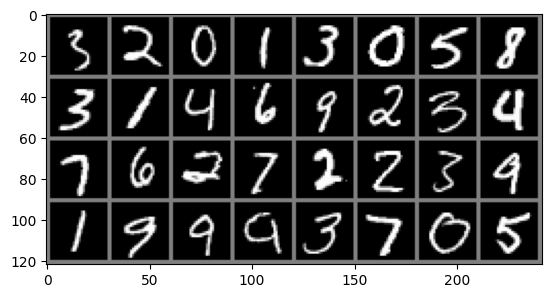

    3     2     0     1     3     0     5     8     3     1     4     6     9     2     3     4     7     6     2     7     2     2     3     9     1     9     9     9     3     7     0     5


In [ ]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % labels[j].item() for j in range(batch_size)))

<H2>2. Generator</H2>
Lập trình kiến trúc Generator theo mô tả phía dưới

In [ ]:
""" Declare GENERATOR.
    + Its input is a 100-feature vector of random noise
    + Its output is a fake image with pixel values in [-1, 1]"""

class Generator(nn.Module):

    ##########################
    ###   YOUR CODE HERE   ###
    ##########################
    def __init__(self):
        super().__init__()
        # self.flatten = nn.Flatten()
        self.sequential = nn.Sequential(
            nn.Linear(100, 256), nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),
            nn.Linear(1024, 784), nn.Tanh() #784 = 28 * 28
        )
    def forward(self, x):
        # x = self.flatten(x)
        logit = self.sequential(x)
        return logit


G = Generator().cuda()
summary(G, (100, ), batch_size=-1, device='cuda')
print("_____________________ Generator Created_____________________")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]          25,856
         LeakyReLU-2                  [-1, 256]               0
       BatchNorm1d-3                  [-1, 256]             512
            Linear-4                  [-1, 512]         131,584
         LeakyReLU-5                  [-1, 512]               0
       BatchNorm1d-6                  [-1, 512]           1,024
            Linear-7                 [-1, 1024]         525,312
         LeakyReLU-8                 [-1, 1024]               0
       BatchNorm1d-9                 [-1, 1024]           2,048
           Linear-10                  [-1, 784]         803,600
             Tanh-11                  [-1, 784]               0
Total params: 1,489,936
Trainable params: 1,489,936
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forw

<H2>3. Discriminator</H2>
Lập trình kiến trúc Discriminator

In [ ]:
""" Declare DISCRIMINATOR
    Its input is REAL IMAGE (in a form of a vector 28x28)
    Its ouput is the probability of image type (REAL IMAGE or FAKE IMAGE)
    the values in the range of [0, 1] """

class Discriminator(nn.Module):
    ##########################
    ###   YOUR CODE HERE   ###
    ##########################
    def __init__(self):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.LeakyReLU(0.2), #28 x 28 x 6
            nn.MaxPool2d(2, 2), #14 x 14 x 6
            nn.Conv2d(6, 16, kernel_size=5), nn.LeakyReLU(0.2), # 10 x 10 x 16
            nn.MaxPool2d(2, 2), #5 x 5 x 16

            nn.Flatten(),
            nn.Linear(400, 120), nn.LeakyReLU(0.2),
            nn.Linear(120, 84), nn.LeakyReLU(0.2),
            nn.Linear(84, 2)
        )

    def forward(self, x):
        logit = self.sequential(x)
        return logit

D = Discriminator().cuda()
summary(D, img_shape, batch_size=-1, device='cuda')
print("____________________ Discriminator Created____________________")


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             156
         LeakyReLU-2            [-1, 6, 28, 28]               0
         MaxPool2d-3            [-1, 6, 14, 14]               0
            Conv2d-4           [-1, 16, 10, 10]           2,416
         LeakyReLU-5           [-1, 16, 10, 10]               0
         MaxPool2d-6             [-1, 16, 5, 5]               0
           Flatten-7                  [-1, 400]               0
            Linear-8                  [-1, 120]          48,120
         LeakyReLU-9                  [-1, 120]               0
           Linear-10                   [-1, 84]          10,164
        LeakyReLU-11                   [-1, 84]               0
           Linear-12                    [-1, 2]             170
Total params: 61,026
Trainable params: 61,026
Non-trainable params: 0
---------------------------------

<h2>4. Generative model</h2>

Xây dựng GAN và huấn luyện

In [ ]:
##########################
###   YOUR CODE HERE   ###
##########################

losses_G = []
losses_D = []
samples = []


criterion = nn.CrossEntropyLoss()
optimizer_G = optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=1e-4, betas=(0.5, 0.999))

In [ ]:
for epoch in range(epochs):
    for (i, (imgs, _)) in enumerate(trainloader, start=1):
        # Adversarial ground truths
        # valid = Variable(torch.cuda.FloatTensor(imgs.size(0), 1).fill_(1.0), requires_grad=False)
        # fake = Variable(torch.cuda.FloatTensor(imgs.size(0), 1).fill_(0.0), requires_grad=False)

        batch_siz = imgs.shape[0]
        valid = torch.ones((batch_siz, 1), requires_grad=False).cuda()
        false = torch.ones((batch_siz, 1), requires_grad=False).cuda()

        # Configure input
        # real_imgs = Variable(imgs.type(torch.cuda.FloatTensor))
        real_imgs = imgs.to(dtype=torch.float).cuda()

        # -----------------
        #  Train Generator
        # -----------------

        optimizer_G.zero_grad()

        # Sample noise as generator input
        # z = Variable(torch.cuda.FloatTensor(np.random.normal(0, 1, (imgs.shape[0], 100))))
        z = torch.normal(mean=0.0, std=1.0, size=(batch_siz, 100)).cuda()
        # Generate a batch of images
        gen_imgs = G(z).view(batch_siz, 1, 28, 28) #reshape

        # Loss measures generator's ability to fool the discriminator

        ##########################
        ###   YOUR CODE HERE   ###
        ##########################
        pred_fakeG = D(gen_imgs) # what D predict picture gen by G
        g_labels = torch.ones(batch_siz, dtype=torch.long).cuda()
        g_loss = criterion(pred_fakeG, g_labels)
        g_loss.backward()
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Loss measures discriminator's ability to classify real from generated samples

        ##########################
        ###   YOUR CODE HERE   ###
        ##########################
        pred_real = D(real_imgs)
        real_labels = torch.ones(batch_siz, dtype=torch.long).cuda()
        d_loss_real = criterion(pred_real, real_labels)

        pred_fake = D(gen_imgs.detach())
        fake_labels = torch.zeros(batch_siz, dtype=torch.long).cuda()
        d_loss_fake = criterion(pred_fake, fake_labels)

        d_loss = (d_loss_fake + d_loss_real) * 0.5
        d_loss.backward()
        optimizer_D.step()

        if epoch % 10 == 0 and i == len(trainloader):
            print(
                "[Epoch %d/%d] [Batch %d/%d] [D loss: %f] [G loss: %f]"
                % (epoch, epochs, i, len(trainloader), d_loss.item(), g_loss.item())
            )

            losses_G.append(g_loss.item())
            losses_D.append(d_loss.item())
            samples.append(gen_imgs)

[Epoch 0/1000] [Batch 1875/1875] [D loss: 0.465823] [G loss: 0.953956]
[Epoch 10/1000] [Batch 1875/1875] [D loss: 0.250637] [G loss: 1.270141]
[Epoch 20/1000] [Batch 1875/1875] [D loss: 0.522364] [G loss: 1.558162]
[Epoch 30/1000] [Batch 1875/1875] [D loss: 0.262183] [G loss: 2.150020]
[Epoch 40/1000] [Batch 1875/1875] [D loss: 0.298132] [G loss: 1.957247]
[Epoch 50/1000] [Batch 1875/1875] [D loss: 0.366325] [G loss: 1.345763]
[Epoch 60/1000] [Batch 1875/1875] [D loss: 0.406004] [G loss: 2.433875]
[Epoch 70/1000] [Batch 1875/1875] [D loss: 0.302481] [G loss: 2.669331]
[Epoch 80/1000] [Batch 1875/1875] [D loss: 0.293362] [G loss: 1.869345]
[Epoch 90/1000] [Batch 1875/1875] [D loss: 0.215490] [G loss: 2.038573]
[Epoch 100/1000] [Batch 1875/1875] [D loss: 0.286635] [G loss: 2.440838]


KeyboardInterrupt: 

### Vẽ đồ thị hàm loss huấn luyện

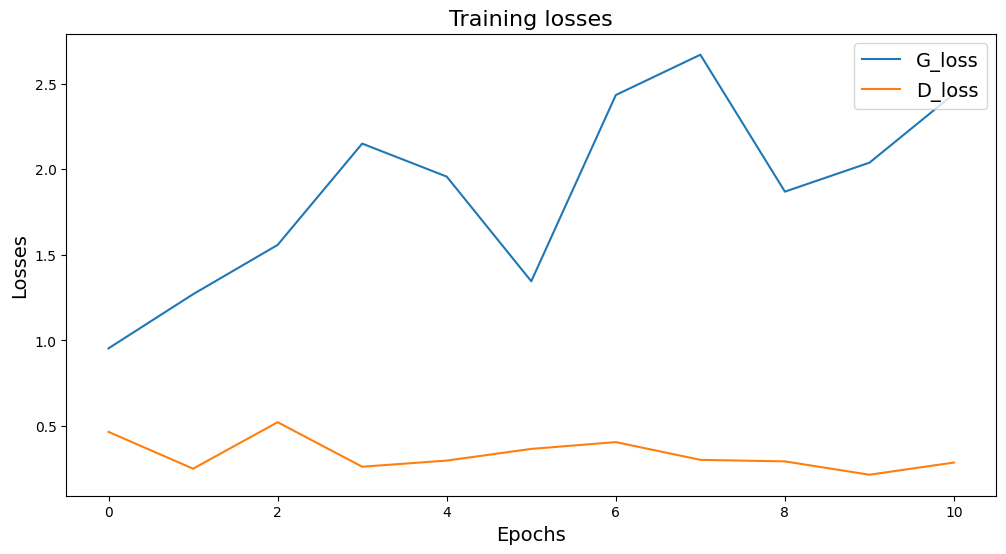

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(len(losses_G)), losses_G, label="G_loss")
plt.plot(range(len(losses_D)), losses_D, label="D_loss")
plt.title("Training losses", fontsize=16)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Losses", fontsize=14)
plt.legend(loc="upper right", fontsize=14)
plt.show()

### Trực quan hoá kết quả sinh dữ liệu của mô hình đã huấn luyện

    ____________________ Step = 0 ____________________    ____________________ Step = 0 ____________________    ____________________ Step = 0 ____________________    ____________________ Step = 0 ____________________    ____________________ Step = 0 ____________________    ____________________ Step = 0 ____________________    ____________________ Step = 0 ____________________    ____________________ Step = 0 ____________________    ____________________ Step = 0 ____________________    ____________________ Step = 0 ____________________


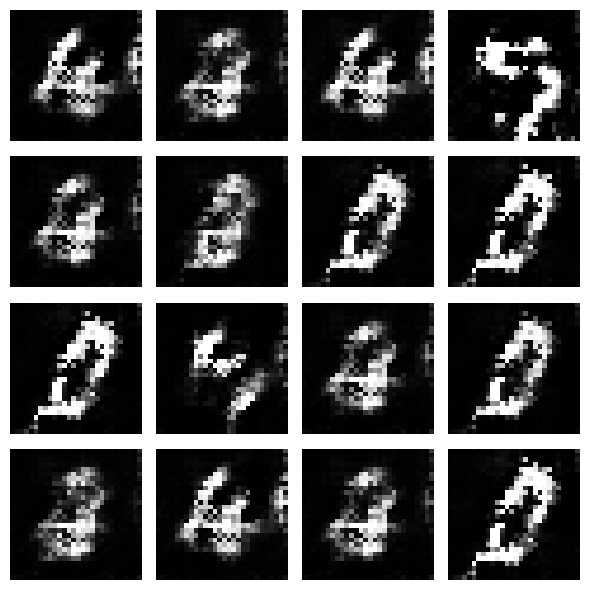



    ____________________ Step = 10 ____________________    ____________________ Step = 10 ____________________    ____________________ Step = 10 ____________________    ____________________ Step = 10 ____________________    ____________________ Step = 10 ____________________    ____________________ Step = 10 ____________________    ____________________ Step = 10 ____________________    ____________________ Step = 10 ____________________    ____________________ Step = 10 ____________________    ____________________ Step = 10 ____________________


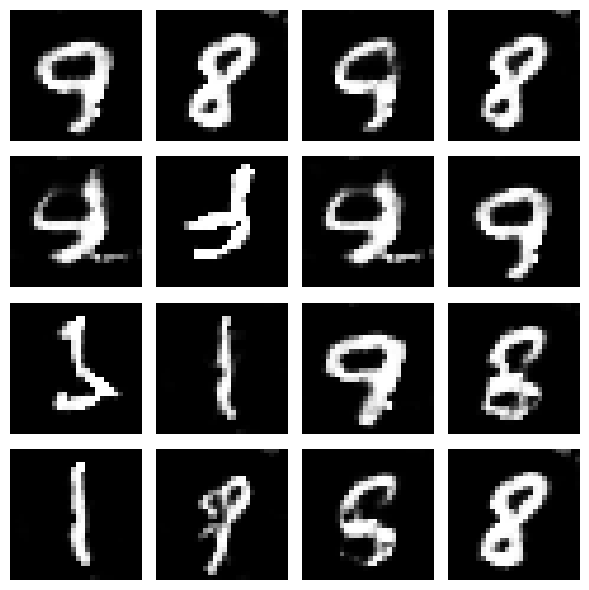

In [ ]:
i = 0
for i in range(0, len(samples), 10):
    images = samples[i].data.cpu().numpy()
    print("    ____________________ Step = %d ____________________" % i*10)
    plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i+1)
        image = images[i, :, :, :]
        image = np.reshape(image, [height, width])
        plt.imshow(image, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print("\n")

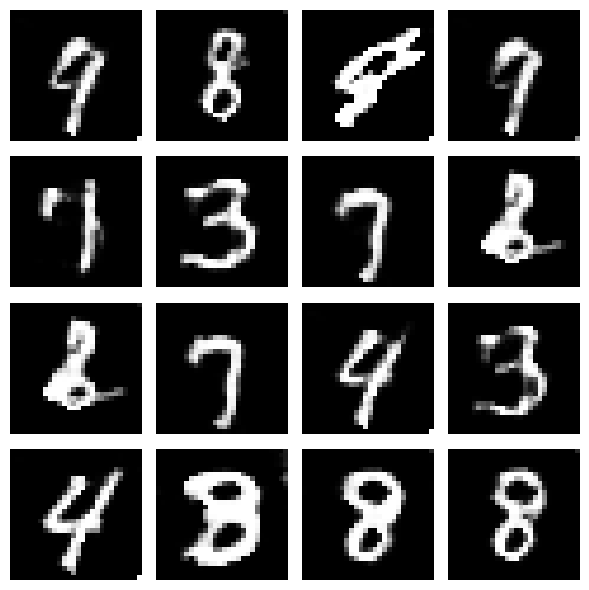

In [ ]:
noise = torch.Tensor(np.random.normal(0, 1, (16, 100))).cuda()
gen_images = G(noise)
images = gen_images.data.cpu().numpy()
plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i+1)
    image = images[i, :]
    image = np.reshape(image, [height, width])
    plt.imshow(image, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()